In [101]:
'''
to create new kernel:
    python -m venv dl_env
    .\dl_env\Scripts\activate
    pip install ipykernel jupyter torch torchvision tensorflow
'''

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Sairaj\AppData\Local\Temp\ipykernel_21116\3204468052.py:4: SyntaxWarning: invalid escape sequence '\d'
  .\dl_env\Scripts\activate


'\nto create new kernel:\n    python -m venv dl_env\n    .\\dl_env\\Scripts\x07ctivate\n    pip install ipykernel jupyter torch torchvision tensorflow\n'

In [102]:
import tensorflow as tf
import sklearn
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras

In [103]:
df = pd.read_csv(r"C:\Users\Sairaj\Downloads\Churn_Modelling\Churn_Modelling.csv")

In [104]:
df.sample(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
5567,5568,15787222,Ch'in,676,Germany,Male,28,1,69459.05,2,1,1,128461.29,0
6707,6708,15735909,McDonald,607,Germany,Female,39,8,105103.33,1,1,0,104721.50,1
2433,2434,15718153,Kao,759,Spain,Female,74,6,128917.84,1,1,1,48244.64,0
8731,8732,15769125,Palerma,727,Spain,Female,41,10,0.00,2,0,1,47468.56,0
4874,4875,15764537,Dominguez,703,France,Male,43,8,0.00,2,1,0,9704.66,0
213,214,15594917,Miller,676,France,Female,34,1,63095.01,1,1,1,40645.81,0
2678,2679,15767793,Hsu,819,France,Female,38,10,0.00,2,1,0,30498.70,0
5428,5429,15623082,Ch'ang,507,France,Female,35,2,0.00,2,1,0,97633.93,0
171,172,15613172,Sun,628,Germany,Male,27,5,95826.49,2,1,0,155996.96,0
152,153,15811589,Metcalfe,716,Spain,Male,42,8,0.00,2,1,0,180800.42,0


In [105]:
x = df.drop(columns = ["RowNumber", "CustomerId", "Surname", "Exited"])
y = df["Exited"]

In [106]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [107]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

p1 = ColumnTransformer(
    transformers = [
        ("encoder", OneHotEncoder(sparse_output = False), ["Geography", "Gender"])
    ], 
    remainder = "passthrough"
)

In [108]:
# Feature scaling is required for anything related to distance (ANN, LiReg, LogReg, KNN, K-Means, SVM, etc)
from sklearn.preprocessing import StandardScaler

p2 = StandardScaler()

In [109]:
pipeline = make_pipeline(p1, p2)

In [110]:
x_train_final = np.array(pipeline.fit_transform(x_train))
x_test_final = np.array(pipeline.transform(x_test))

In [111]:
# Creating the Artificial Neural Network (ANN)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import ReLU, LeakyReLU, PReLU, ELU
from tensorflow.keras.layers import Dropout

In [112]:
# Sequential helps us to do forward and backward propagation 
# Dense helps us to create the layers 
# ReLU, LeakyReLU, PReLU, ELU are all activation functions
# Dropout is a regularization technique to prevent overfitting

In [113]:
# Initializing the ANN
classifier = Sequential()

In [114]:
# Adding the input layer 
classifier.add(Dense(units = 11, activation = "relu"))

In [115]:
# Adding the first hidden layer
classifier.add(Dense(units = 7, activation = "relu"))

In [116]:
# Adding the second hidden layer
classifier.add(Dense(units = 5, activation = "relu"))

In [117]:
# Adding the output layer
classifier.add(Dense(units = 1, activation = "sigmoid"))

In [118]:
opt = tf.keras.optimizers.Adam(learning_rate = 0.01)

In [119]:
classifier.compile(optimizer = opt, loss = "binary_crossentropy", metrics = ["accuracy"])

In [23]:
model = classifier.fit(x_train_final, y_train, validation_split = 0.33, batch_size = 10, epochs = 1000)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7434 - loss: 0.5488 - val_accuracy: 0.7910 - val_loss: 0.4669
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7962 - loss: 0.4461 - val_accuracy: 0.7910 - val_loss: 0.4467
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7968 - loss: 0.4273 - val_accuracy: 0.7936 - val_loss: 0.4352
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8181 - loss: 0.4109 - val_accuracy: 0.8334 - val_loss: 0.4172
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8380 - loss: 0.3879 - val_accuracy: 0.8364 - val_loss: 0.3976
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8507 - loss: 0.3677 - val_accuracy: 0.8440 - val_loss: 0.3833
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8543 - loss: 0.3545 - val_accuracy: 0.8485 - val_loss: 0.3795
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8586 - loss: 0.3474 - 

In [120]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor = "val_loss",
    min_delta = 0.01,
    patience = 10,
    verbose = 1,
    mode = "auto",
    baseline = None,
    restore_best_weights = False,
    start_from_epoch = 0,
)

# used to prevent overfitting 

In [121]:
model = classifier.fit(x_train_final, y_train, validation_split = 0.33, batch_size = 10, epochs = 1000, callbacks = early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8121 - loss: 0.4281 - val_accuracy: 0.8251 - val_loss: 0.3933
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8457 - loss: 0.3677 - val_accuracy: 0.8326 - val_loss: 0.3848
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8539 - loss: 0.3576 - val_accuracy: 0.8372 - val_loss: 0.3779
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8567 - loss: 0.3499 - val_accuracy: 0.8436 - val_loss: 0.3820
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8548 - loss: 0.3503 - val_accuracy: 0.8395 - val_loss: 0.3835
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8565 - loss: 0.3457 - val_accuracy: 0.8410 - val_loss: 0.3875
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8619 - loss: 0.3428 - val_accuracy: 0.8395 - val_loss: 0.3766
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8642 - loss: 0.3445 - 

In [122]:
model.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

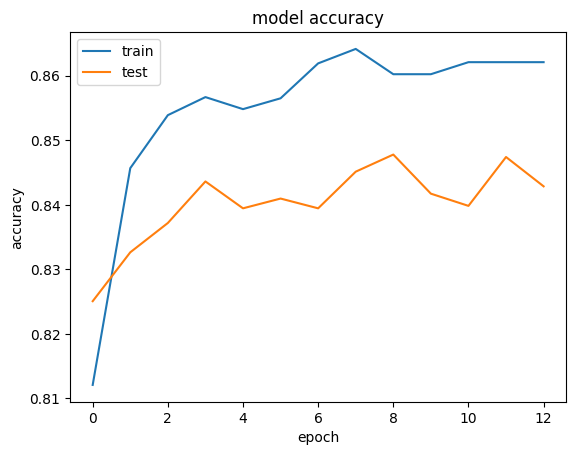

In [123]:
# Summary

plt.plot(model.history['accuracy']) 
plt.plot(model.history['val_accuracy']) 
plt.title('model accuracy') 
plt.ylabel('accuracy') 
plt.xlabel('epoch') 
plt.legend(['train', 'test'], loc='upper left') 
plt.show()

In [124]:
# Prediction on test data

y_pred = classifier.predict(x_test_final)
y_pred = (y_pred >= 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [125]:
# Making the confusion matrix 
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1536   71]
 [ 226  167]]


In [126]:
# Calculating the accuracy 
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {accuracy*100:.2f}%")

Final Test Accuracy: 85.15%


In [127]:
# Getting the weights

classifier.get_weights()

[array([[-1.20008957e+00,  1.10134864e+00, -6.65556073e-01,
          9.00747851e-02,  3.46704200e-02, -3.37166369e-01,
          1.91756979e-01, -4.53354657e-01,  3.38011950e-01,
         -2.38492005e-02,  3.28308135e-01],
        [ 7.87983537e-01, -4.74381685e-01,  5.70061207e-01,
          6.28482103e-01, -1.80371091e-01, -4.75968093e-01,
         -9.43769455e-01,  7.26880014e-01,  1.93288490e-01,
         -4.09101807e-02,  5.70657253e-01],
        [ 5.92396438e-01, -1.01141930e+00,  5.36209047e-01,
          1.41972050e-01,  4.24258083e-01,  8.19446519e-02,
          7.00906754e-01, -2.21779317e-01, -1.43662542e-02,
          2.96815671e-02,  5.52106053e-02],
        [ 5.70119381e-01, -3.06458414e-01, -2.30436996e-01,
          1.57426625e-01,  1.49250910e-01, -8.43477190e-01,
         -3.69159997e-01, -4.12203789e-01, -1.14583775e-01,
         -6.09211683e-01,  5.07629924e-02],
        [-7.18758583e-01, -9.57085490e-02,  6.74511015e-01,
          2.38925032e-02,  1.04352713e-01,  

In [128]:
# Saving the Scikit-learn pipeline
import joblib

joblib.dump(pipeline, 'churn_pipeline.pkl')

['churn_pipeline.pkl']

In [129]:
# Saving the Tensorflow/Keras ANN model

classifier.save('churn_model.keras')